# Calibration and Gold Standard Comparison Workshop

### Overview
In this activity you will collect data from a sensor and perform a calibration. You will use either a temperature sensor or a position sensor.

### Materials
You will be using a sensor connected to an Arduino that you will connect to your computer. The Arduino is running a sketch that outputs the sensor reading over a serial line at a frequency of approximately 10Hz. 

### Methods

##### Data Collection
This notebook reads the values from your computer's serial port. Each reading will consist of 1 ground truth value which you will enter and 10 samples from the sensor. This will allow you to assess the variability of the sensor's output. 

##### Data Analysis
To analyze your data you will:

- Calculate the mean and standard deviation for each reading
- Plot a calibration curve using linear regression to fit the curve to your data
- Plot the mean and standard deviation on the same plot using error bars
- Use the equation of the calibration curve to calibrate the readings from the sensor
- Generate a Bland-Altman or Mean-Difference plot to assess the agreement of the sensors



In [14]:
import numpy as np #numpy provides a 'matlab like' syntax for array manipulation
import matplotlib.pyplot as plt #matplotlib provides a 'matlab like' syntax for generating plots and visualizing data
import serial #serial allows the jupyter notebook to interact with a serial connection (i.e., the Arduino)
import time #time allows data to be used
from scipy import stats

com_port = 'COM7' # update to match your com port
num_samples = 100 # How many samples we want to collect for each reading

In [15]:
def read_serial_samples(port=com_port, baudrate=9600, num_samples=10, timeout=1,verbose=False):
    """
    Reads a specified number of samples from a serial port.

    Parameters:
        port (str): Serial port name (e.g., 'COM3' on Windows or '/dev/ttyUSB0' on Linux).
        baudrate (int): Baud rate for the serial communication.
        num_samples (int): Number of samples to read.
        timeout (float): Timeout in seconds for serial read.

    Returns:
        list: A list of samples from the serial port.
    """
    samples = []
    try:
        # Open the serial connection
        ser = serial.Serial(port, baudrate, timeout=timeout)
        time.sleep(2)  # Allow time for Arduino to reset

        print(f"Reading {num_samples} samples from {port}...")
        while len(samples) < num_samples:
            if ser.in_waiting > 0:
                line = float(ser.readline().decode('utf-8').strip())
                print(f"Received: {line}")
                samples.append(line)
                if verbose:
                    print(f"Sample {len(samples)}: {line}")

        ser.close()
        return samples

    except serial.SerialException as e:
        print(f"Error: {e}")
        return []

true_values = [] #We'll store the ground truth readings here
sensor_readings = [] #We'll store the sensor readings here


### Collect Calibration Data
The following code block is configured to collect your calibration data. To use the block: 
1. Enter the ground truth value into the 'true_val' variable and run the block.
2. The code will read a predetermined number of samples from the serial port.
3. Provided no errors occur the true value and sample pair will each be appended to their respictive list for subsequent analysis.
4. A histogram of the sample data will be plotted to provide some insight into the distribution of the sensor data.
5. Repeat the same procedure to collect as many points as you need for the calibration.

Reading 100 samples from COM7...
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 170.0
Received: 171.0
Received: 171.0
Received: 171.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 169.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Received: 170.0
Receive

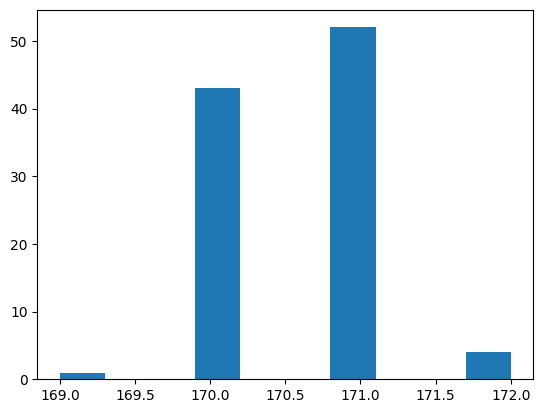

Collected samples mean +/- standard deviation:  170.59 +/-  0.58


In [25]:
#Collect Data:

true_val = 20
sample_val = read_serial_samples(port=com_port, baudrate=9600, num_samples=num_samples)

if len(sample_val)==num_samples:
    true_values.append(true_val)
    sensor_readings.append(sample_val)

#Visualize your samples with a histogram to see how many the distribution looks like
plt.figure()
plt.hist(sample_val)
plt.show()

avg = np.mean(sample_val) 
std = np.std(sample_val)

output = f"Collected samples mean +/- standard deviation: {avg: .2f} +/- {std: .2f}"
print(output)

In [26]:
print(true_values,sensor_readings)

[2, 4, 6, 8, 10, 12, 14, 16, 18, 20] [[166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 167.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 166.0, 166.0, 166.0, 167.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 165.0, 165.0, 165.0, 165.0, 165.0, 165.0, 165.0, 165.0, 165.0, 165.0, 165.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0], [166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 166.0, 167.0, 167.0, 166.0, 166.0, 166.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 167.0, 166.0, 166.0, 166.0, 166.0, 167.0, 167.0, 167.0, 

### Mean, Standard Deviation, and Regression

Here we will calculate the mean standard deviation and regression line for the collected data

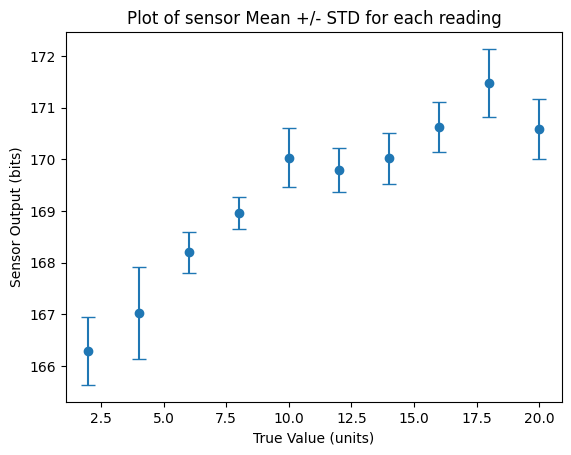

In [27]:
# Aggregate the data and plot with errorbars

mean_sensor_readings = np.mean(sensor_readings, axis=1)
std_sensor_readings = np.std(sensor_readings, axis=1)

plt.figure()
plt.title('Plot of sensor Mean +/- STD for each reading')
plt.xlabel('True Value (units)')
plt.ylabel('Sensor Output (bits)')
plt.errorbar(true_values,mean_sensor_readings, yerr = std_sensor_readings, fmt='None', capsize=5)
plt.scatter(true_values,mean_sensor_readings)
plt.show()



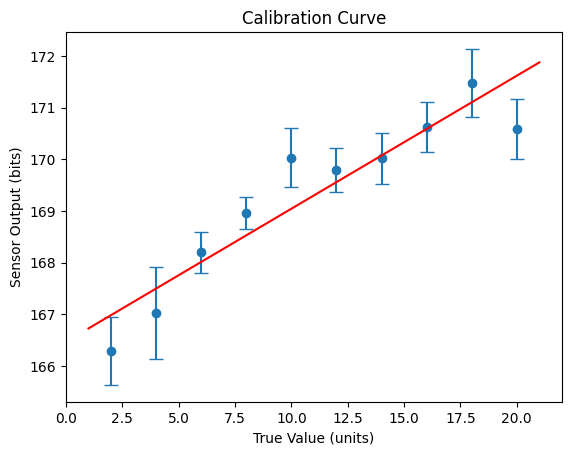

In [28]:
#Fit the calibration curve and plot the curve

slope, intercept, r_value, p_value, std_err = stats.linregress(true_values, mean_sensor_readings) 

fit_x = np.array((min(true_values)-1, max(true_values)+1))
fit_y = fit_x*slope+intercept

plt.figure()
plt.title('Calibration Curve')
plt.xlabel('True Value (units)')
plt.ylabel('Sensor Output (bits)')
plt.errorbar(true_values,mean_sensor_readings, yerr = std_sensor_readings, fmt='None', capsize=5)
plt.scatter(true_values,mean_sensor_readings)
plt.plot(fit_x,fit_y, 'r')

plt.show()


### Bland-Altman Analysis

Bland-Altman plots, or Mean-Difference plots are a tool that allow you to examine the agreement between two interventions or methods of measurement. This is particularly useful when you have a "gold-standard" measurement to which you are comparing.

When creating a Bland-Altman plot, you will have two sets of data:
- Gold-Standard Data
- Experimental Data

You use these inputs to create two additional quantities:
- The mean of the Gold-Standard and Experimental data
- The difference of the Gold-Standard and experimental data

The mean and difference are calculated for each observation in the original dataset. Three subsequent values are also computed to help structure the plot:
- The Mean of the Difference data
- The Standard Deviation of the Difference data
- The 95% limit of agreement (1.96*STD)

The Mean of the difference +/- the 95% limits of agreement are drawn on the figure as horizontal lines. 


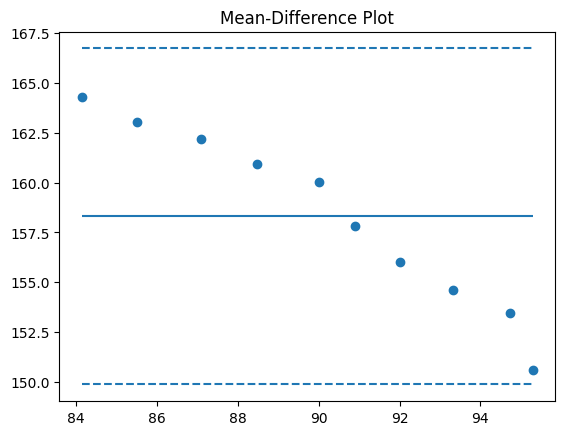

[84.145 85.515 87.1   88.48  90.015 90.9   92.01  93.31  94.74  95.295]
[164.29 163.03 162.2  160.96 160.03 157.8  156.02 154.62 153.48 150.59]


In [29]:
# Bland-Altman Plot Creation

# Stack Data into an array with both the sensor readings and true values
# vstack stacks vertically, the resultant array will have 2 rows and N columns, where N is the number of readings you took
data = np.vstack((mean_sensor_readings, true_values))

mean_vals = np.mean(data, axis=0)
diff_vals = data[0,:] - data[1,:]

mean_diff = np.mean(diff_vals)
limits_of_agreement = 1.96*np.std(diff_vals)

plt.figure()
plt.title('Mean-Difference Plot')
plt.scatter(mean_vals, diff_vals)
plt.hlines(mean_diff, xmin=min(mean_vals), xmax=max(mean_vals))
plt.hlines(mean_diff+limits_of_agreement, xmin=min(mean_vals), xmax=max(mean_vals), linestyles='dashed')
plt.hlines(mean_diff-limits_of_agreement, xmin=min(mean_vals), xmax=max(mean_vals), linestyles='dashed')
plt.show()

print(mean_vals)
print(diff_vals)